In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

class CarDealershipSentimentAnalyzer:
    def __init__(self):
        self.model = None
        self.tokenizer = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    def load_all_dealership_data(self, data_directory="./FYP-Testing-Data.csv/"):
        """
        Load all dealership CSV files and combine them
        """
        all_data = []
        
        # Get all CSV files in the directory
        csv_files = glob(os.path.join(data_directory, "*.csv"))
        
        for file_path in csv_files:
            try:
                # Extract dealership name from filename
                dealership_name = os.path.basename(file_path).replace('.csv', '')
                
                # Load the CSV
                df = pd.read_csv(file_path, encoding='unicode_escape')
                
                # Add dealership name column
                df['dealership'] = dealership_name
                
                all_data.append(df)
                print(f"Loaded {len(df)} records from {dealership_name}")
                
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
        
        # Combine all data
        if all_data:
            combined_data = pd.concat(all_data, ignore_index=True)
            print(f"\nTotal records loaded: {len(combined_data)}")
            return combined_data
        else:
            raise ValueError("No data files found!")
    
    def preprocess_data(self, df, text_column, label_column):
        """
        Clean and preprocess the data
        """
        # Remove rows with missing text or labels
        df_clean = df.dropna(subset=[text_column, label_column]).copy()
        
        # Clean text data
        df_clean[text_column] = df_clean[text_column].astype(str)
        df_clean[text_column] = df_clean[text_column].str.strip()
        
        # Standardize labels (assuming manual labels are 'positive'/'negative')
        label_mapping = {
            'positive': 1,
            'negative': 0,
            'Positive': 1,
            'Negative': 0,
            1: 1,
            0: 0
        }
        
        df_clean['label'] = df_clean[label_column].map(label_mapping)
        df_clean = df_clean.dropna(subset=['label'])
        
        print(f"Cleaned data shape: {df_clean.shape}")
        print(f"Label distribution:\n{df_clean['label'].value_counts()}")
        
        return df_clean
    
    def create_dataset_class(self):
        """
        Create a custom dataset class for PyTorch
        """
        class SentimentDataset(Dataset):
            def __init__(self, texts, labels, tokenizer, max_length=512):
                self.texts = texts
                self.labels = labels
                self.tokenizer = tokenizer
                self.max_length = max_length
            
            def __len__(self):
                return len(self.texts)
            
            def __getitem__(self, idx):
                text = str(self.texts[idx])
                label = self.labels[idx]
                
                encoding = self.tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=self.max_length,
                    return_tensors='pt'
                )
                
                return {
                    'input_ids': encoding['input_ids'].flatten(),
                    'attention_mask': encoding['attention_mask'].flatten(),
                    'labels': torch.tensor(label, dtype=torch.long)
                }
        
        return SentimentDataset
    
    def train_custom_model(self, df, text_column, label_column, test_size=0.2):
        """
        Train a custom model on your dealership data
        """
        # Preprocess data
        df_clean = self.preprocess_data(df, text_column, label_column)
        
        # Split data
        train_texts, val_texts, train_labels, val_labels = train_test_split(
            df_clean[text_column].tolist(),
            df_clean['label'].tolist(),
            test_size=test_size,
            random_state=42,
            stratify=df_clean['label']
        )
        
        # Initialize tokenizer and model
        model_name = "distilbert-base-uncased"  # Lighter than RoBERTa
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, 
            num_labels=2
        )
        
        # Create datasets
        SentimentDataset = self.create_dataset_class()
        train_dataset = SentimentDataset(train_texts, train_labels, self.tokenizer)
        val_dataset = SentimentDataset(val_texts, val_labels, self.tokenizer)
        
        # Training arguments
        training_args = TrainingArguments(
            output_dir='./results',
            num_train_epochs=3,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=16,
            warmup_steps=500,
            weight_decay=0.01,
            logging_dir='./logs',
            logging_steps=100,
            evaluation_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
        )
        
        # Initialize trainer
        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
        )
        
        # Train model
        print("Starting training...")
        trainer.train()
        
        # Evaluate on validation set
        predictions = trainer.predict(val_dataset)
        y_pred = np.argmax(predictions.predictions, axis=1)
        
        # Print results
        print("\nValidation Results:")
        print(f"Accuracy: {accuracy_score(val_labels, y_pred):.4f}")
        print("\nClassification Report:")
        print(classification_report(val_labels, y_pred, target_names=['Negative', 'Positive']))
        
        # Save model
        self.model.save_pretrained('./car_dealership_sentiment_model')
        self.tokenizer.save_pretrained('./car_dealership_sentiment_model')
        
        return trainer, val_labels, y_pred
    
    def predict_sentiment(self, text):
        """
        Predict sentiment for a single text
        """
        if not self.model or not self.tokenizer:
            # Load saved model if not already loaded
            self.load_saved_model('./car_dealership_sentiment_model')
        
        inputs = self.tokenizer(text, return_tensors='pt', truncation=True, padding=True)
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
            predicted_class = torch.argmax(predictions, dim=1).item()
            confidence = predictions[0][predicted_class].item()
        
        sentiment = 'Positive' if predicted_class == 1 else 'Negative'
        return sentiment, confidence
    
    def load_saved_model(self, model_path):
        """
        Load a previously saved model
        """
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        print(f"Model loaded from {model_path}")
    
    def batch_analyze_dealership(self, file_path, text_column):
        """
        Analyze sentiment for all reviews in a dealership file
        """
        df = pd.read_csv(file_path, encoding='unicode_escape')
        df['predicted_sentiment'] = ''
        df['confidence'] = ''
        
        for index, row in df.iterrows():
            text = str(row[text_column])
            if text and text != 'nan':
                sentiment, confidence = self.predict_sentiment(text)
                df.at[index, 'predicted_sentiment'] = sentiment
                df.at[index, 'confidence'] = confidence
        
        return df
    
    def generate_insights_report(self, df, dealership_name):
        """
        Generate comprehensive insights for a dealership
        """
        insights = {}
        
        # Basic sentiment distribution
        sentiment_counts = df['predicted_sentiment'].value_counts()
        total_reviews = len(df)
        
        insights['total_reviews'] = total_reviews
        insights['positive_count'] = sentiment_counts.get('Positive', 0)
        insights['negative_count'] = sentiment_counts.get('Negative', 0)
        insights['positive_percentage'] = (insights['positive_count'] / total_reviews) * 100
        insights['negative_percentage'] = (insights['negative_count'] / total_reviews) * 100
        
        # Confidence analysis
        insights['avg_confidence'] = df['confidence'].mean()
        insights['high_confidence_reviews'] = len(df[df['confidence'] > 0.8])
        
        # Create visualizations
        self.create_sentiment_visualizations(df, dealership_name)
        
        return insights

    def create_sentiment_visualizations(self, df, dealership_name):
        """
        Create visualization charts
        """
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
        
        # Sentiment distribution pie chart
        sentiment_counts = df['predicted_sentiment'].value_counts()
        ax1.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')
        ax1.set_title(f'{dealership_name} - Sentiment Distribution')
        
        # Sentiment over time (if date column exists)
        # This would require a date column in your data
        
        # Confidence distribution
        ax2.hist(df['confidence'], bins=20, edgecolor='black')
        ax2.set_title('Confidence Score Distribution')
        ax2.set_xlabel('Confidence Score')
        ax2.set_ylabel('Frequency')
        
        # Sentiment vs Confidence scatter
        colors = ['red' if x == 'Negative' else 'green' for x in df['predicted_sentiment']]
        ax3.scatter(range(len(df)), df['confidence'], c=colors, alpha=0.6)
        ax3.set_title('Sentiment vs Confidence')
        ax3.set_xlabel('Review Index')
        ax3.set_ylabel('Confidence Score')
        
        # Top confident predictions
        high_conf = df.nlargest(10, 'confidence')
        ax4.barh(range(len(high_conf)), high_conf['confidence'])
        ax4.set_title('Top 10 Most Confident Predictions')
        ax4.set_xlabel('Confidence Score')
        
        plt.tight_layout()
        plt.savefig(f'{dealership_name}_sentiment_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

# Usage Example
if __name__ == "__main__":
    # Initialize analyzer
    print("Running")
    analyzer = CarDealershipSentimentAnalyzer()
    
    # Method 1: Train custom model on all your data
    try:
        # Load all dealership data
        all_data = analyzer.load_all_dealership_data("./your_data_directory/")
        
        # Train custom model (assuming you have manual labels)
        trainer, val_labels, y_pred = analyzer.train_custom_model(
            all_data, 
            text_column="wiI7pd",  # your review text column
            label_column="manual_label"  # your manual label column
        )
        
    except Exception as e:
        print(f"Training failed: {e}")
        print("Loading pre-trained model instead...")
    
    # Method 2: Use the trained model for analysis
    try:
        # Load your trained model
        analyzer.load_saved_model('./car_dealership_sentiment_model')
        
        # Analyze a specific dealership
        dealership_df = analyzer.batch_analyze_dealership(
            "Suzuki Adil Zafar Motors.csv", 
            "wiI7pd"
        )
        
        # Generate insights
        insights = analyzer.generate_insights_report(dealership_df, "Suzuki Adil Zafar Motors")
        
        print("Insights:", insights)
        
        # Save results
        dealership_df.to_csv("analyzed_suzuki_results.csv", index=False)
        
    except Exception as e:
        print(f"Analysis failed: {e}")

ModuleNotFoundError: No module named 'transformers'

In [5]:
# Core packages
pip install transformers torch torchvision torchaudio
pip install scikit-learn pandas numpy matplotlib seaborn
pip install datasets accelerate

# If you're using GPU (optional)
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

SyntaxError: invalid syntax (494736806.py, line 2)

=== USING PRE-TRAINED MODEL (No Training Required) ===
✓ Created rule-based sentiment model

=== ANALYZING ALL DEALERSHIPS ===
Found 11 CSV files
Loaded 1377 records from FYP-Testing-Data
Loaded 458 records from Suzuki Khalid Motors (Link Ferozpur)
Loaded 298 records from Suzuki Adil Zafar Motors
Loaded 664 records from Suzuki Raiwing Motors (Raiwind Rd)
Loaded 429 records from HONDA Township
Loaded 429 records from HONDA Gateway
Loaded 412 records from HONDA Fort
Loaded 209 records from HONDA RingRoad
Loaded 527 records from Suzuki Mini Motors (Gulberg 3)
Loaded 440 records from HONDA Point
Loaded 759 records from Suzuki Sethi Motors (Town Morr)
Total records: 6002
Found 11 dealerships to analyze

--- Analyzing FYP-Testing-Data ---
✓ Analyzed 971 reviews
  Positive: 41.6%
  Negative: 58.4%


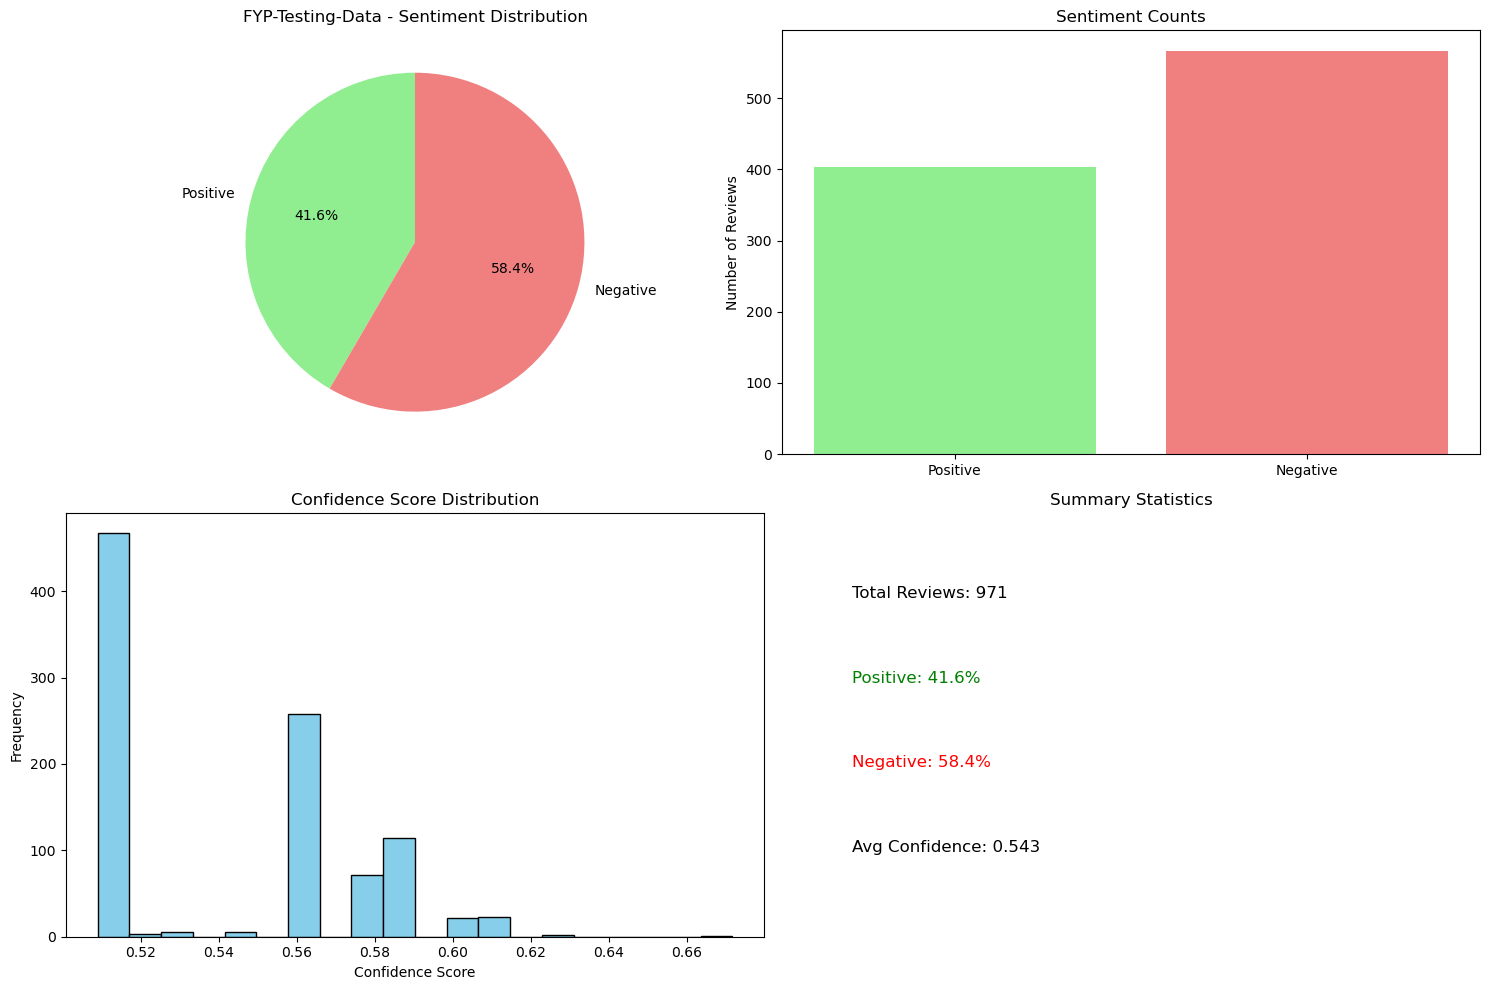


--- Analyzing Suzuki Khalid Motors (Link Ferozpur) ---
✓ Analyzed 360 reviews
  Positive: 47.8%
  Negative: 52.2%


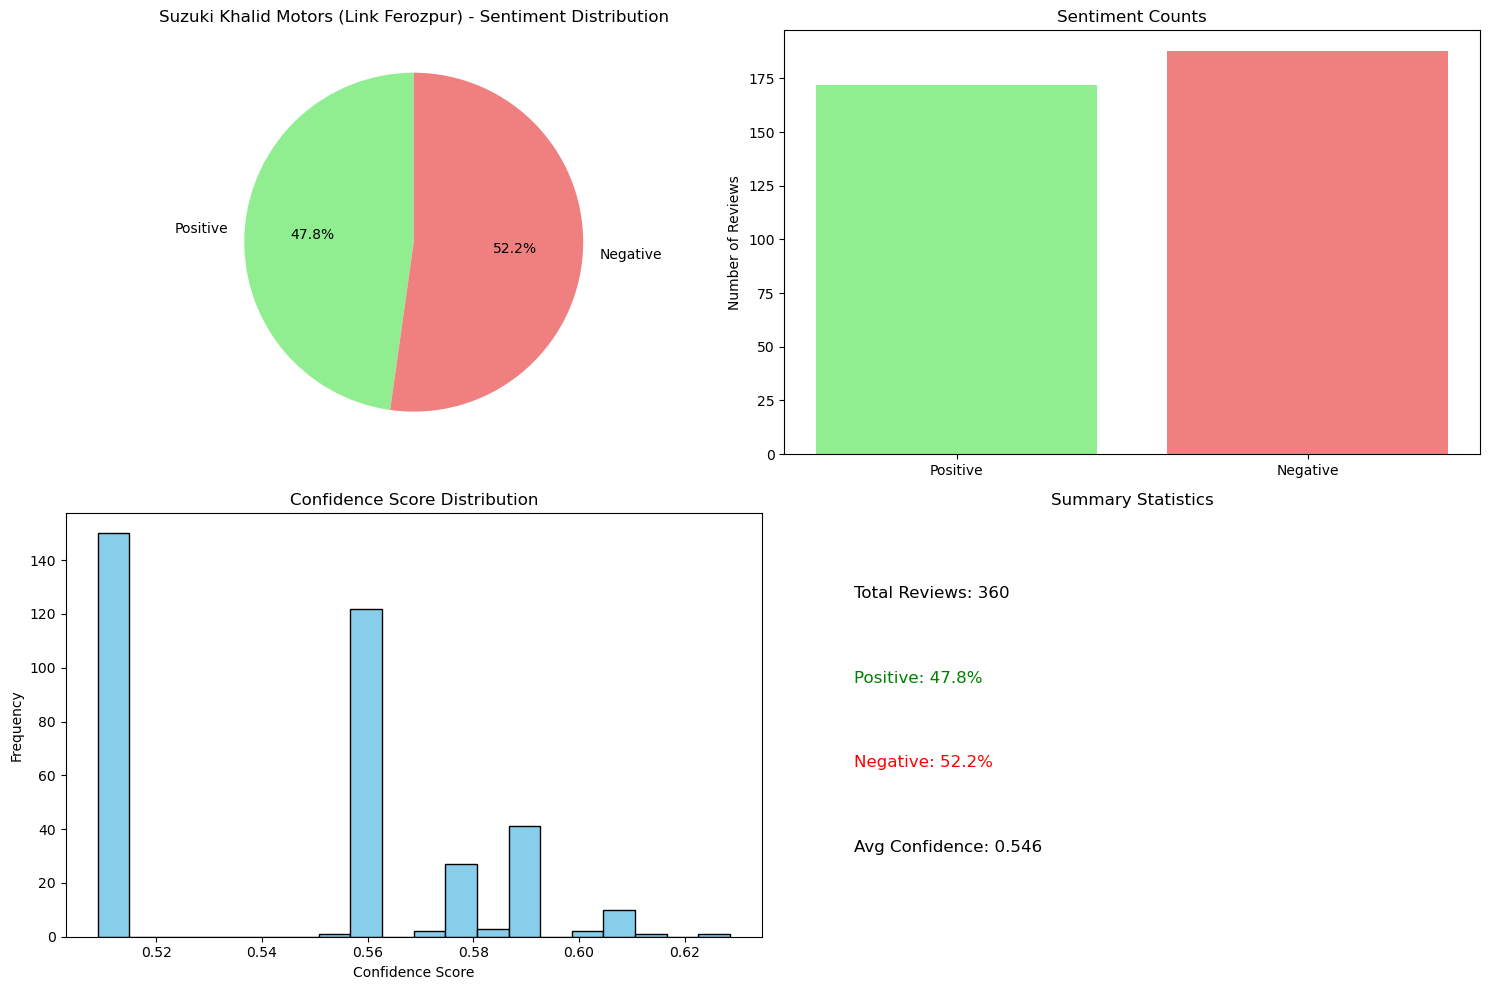


--- Analyzing Suzuki Adil Zafar Motors ---
✓ Analyzed 252 reviews
  Positive: 51.2%
  Negative: 48.8%


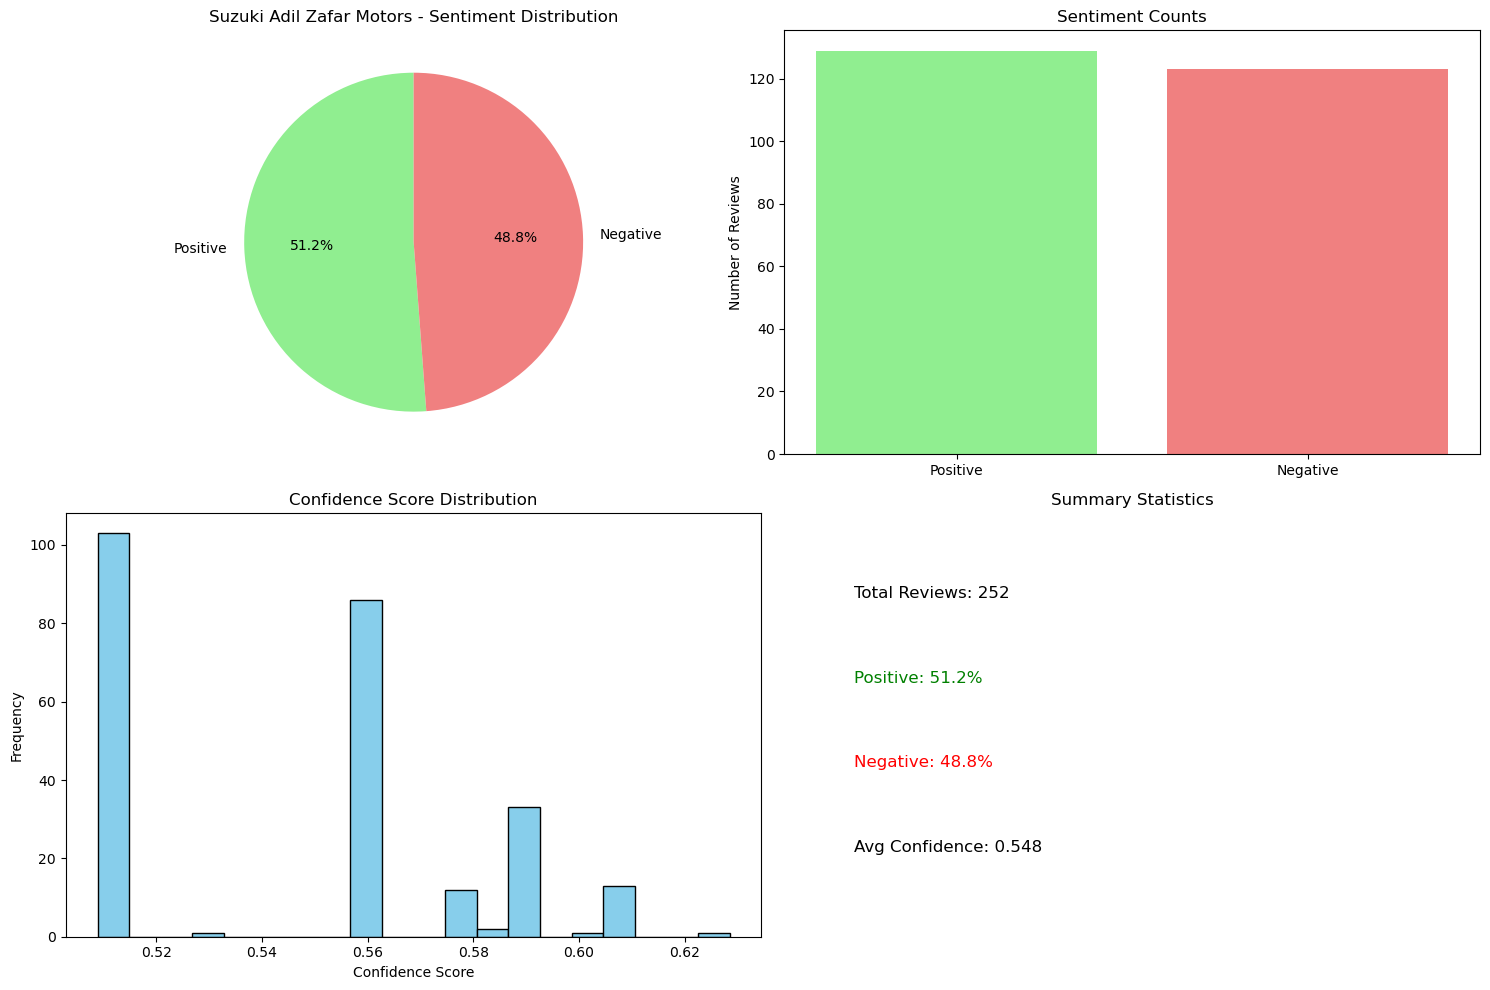


--- Analyzing Suzuki Raiwing Motors (Raiwind Rd) ---
✓ Analyzed 616 reviews
  Positive: 0.2%
  Negative: 99.8%


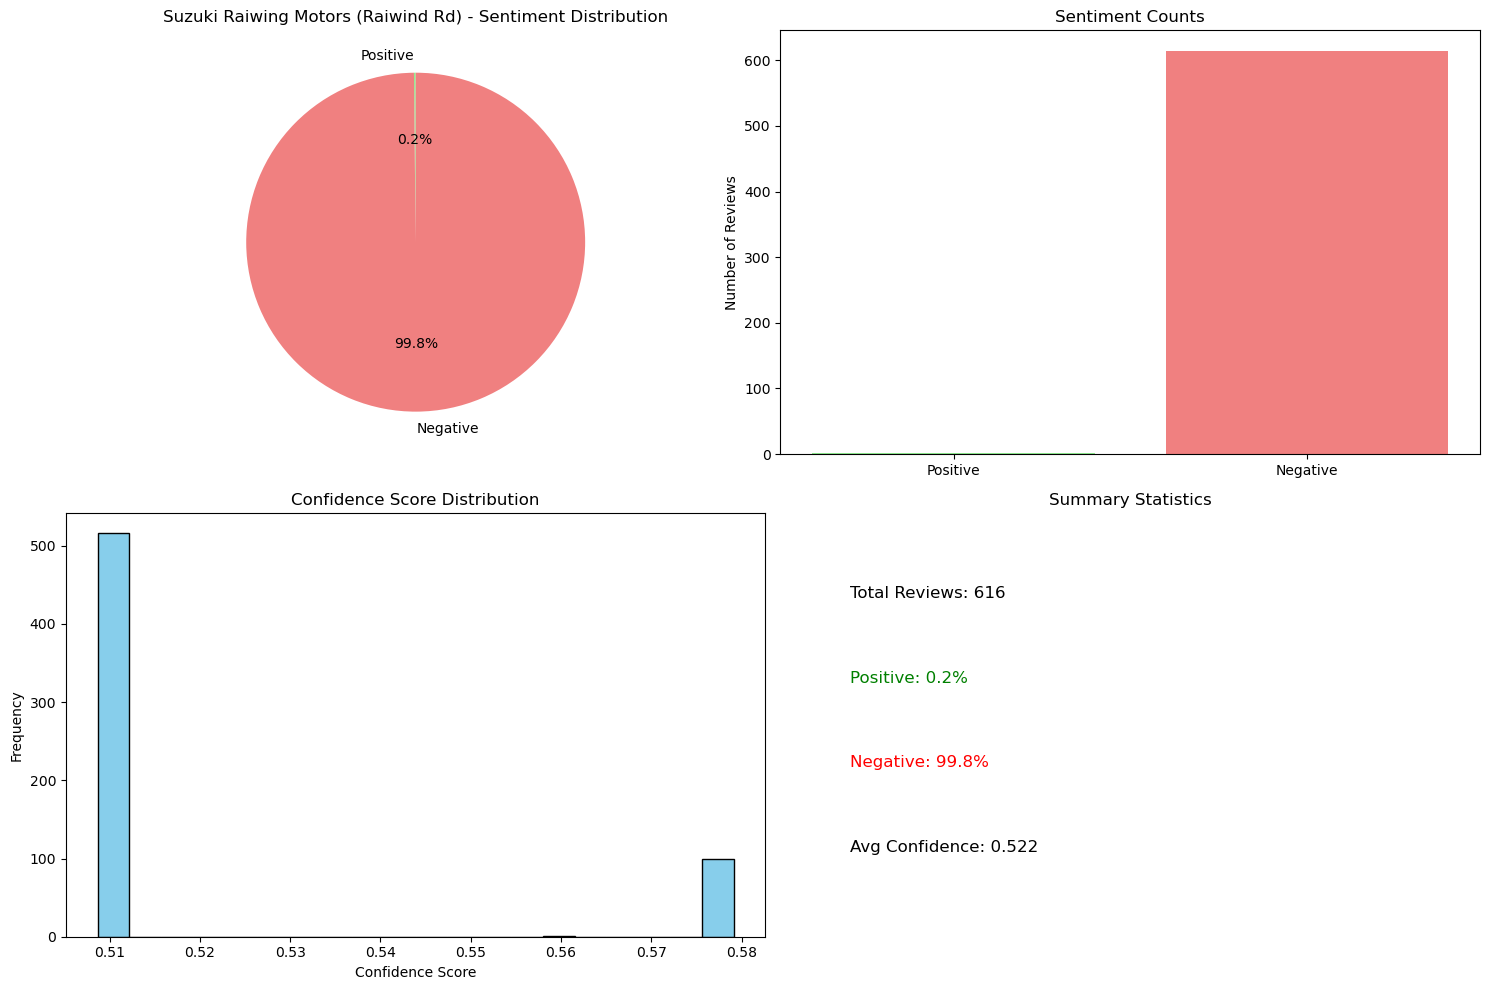


--- Analyzing HONDA Township ---
✓ Analyzed 363 reviews
  Positive: 59.5%
  Negative: 40.5%


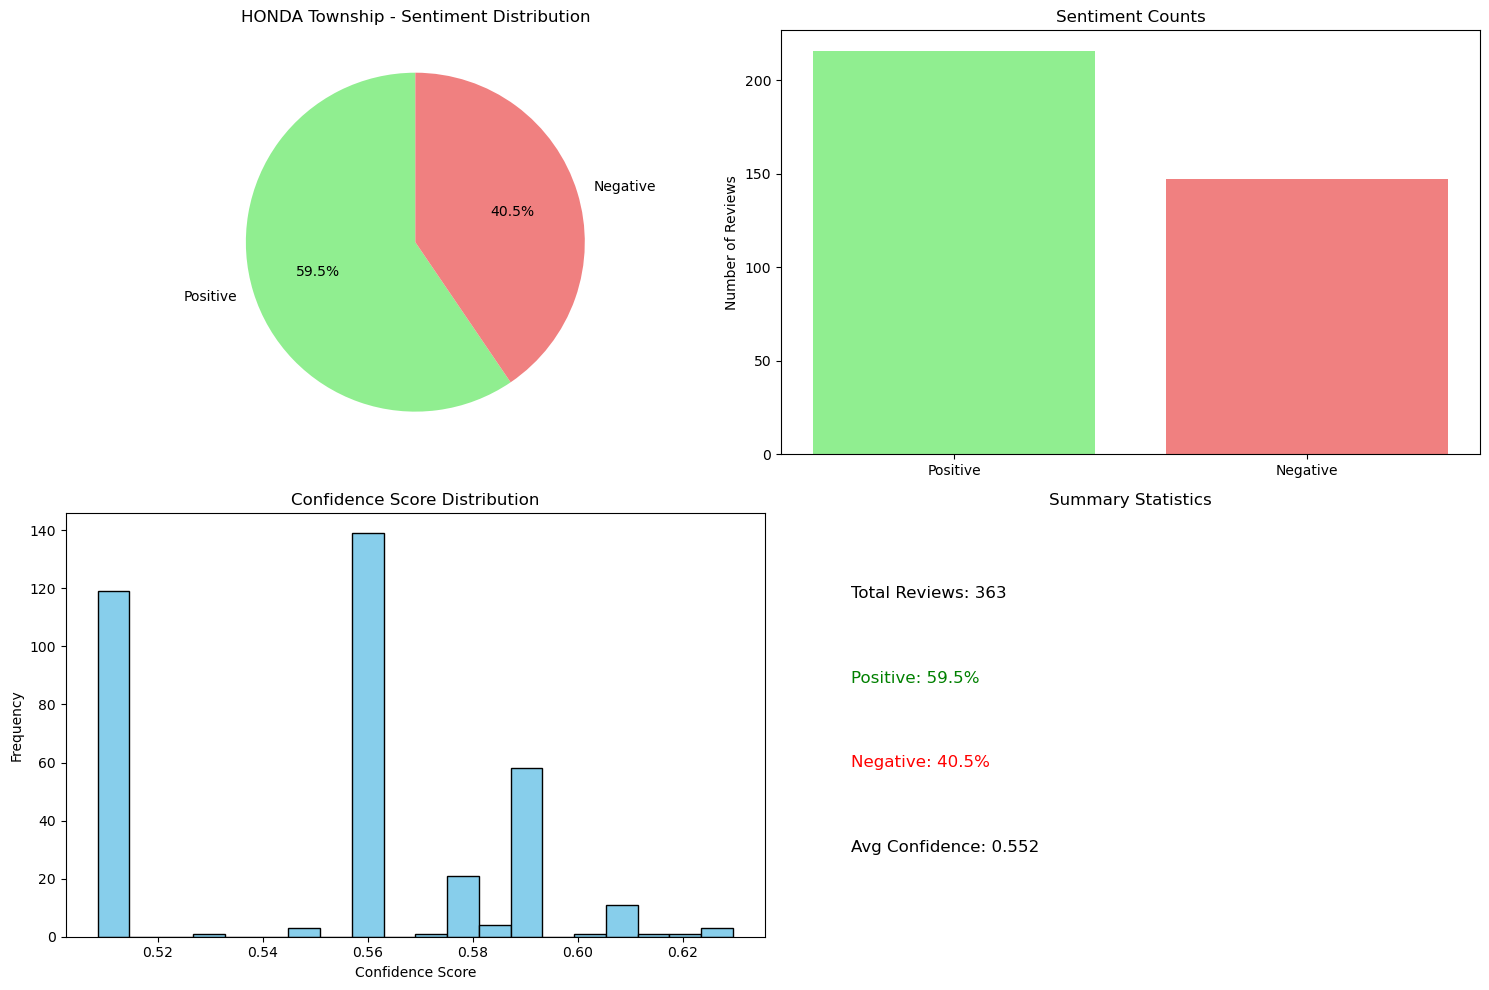


--- Analyzing HONDA Gateway ---
✓ Analyzed 356 reviews
  Positive: 45.5%
  Negative: 54.5%


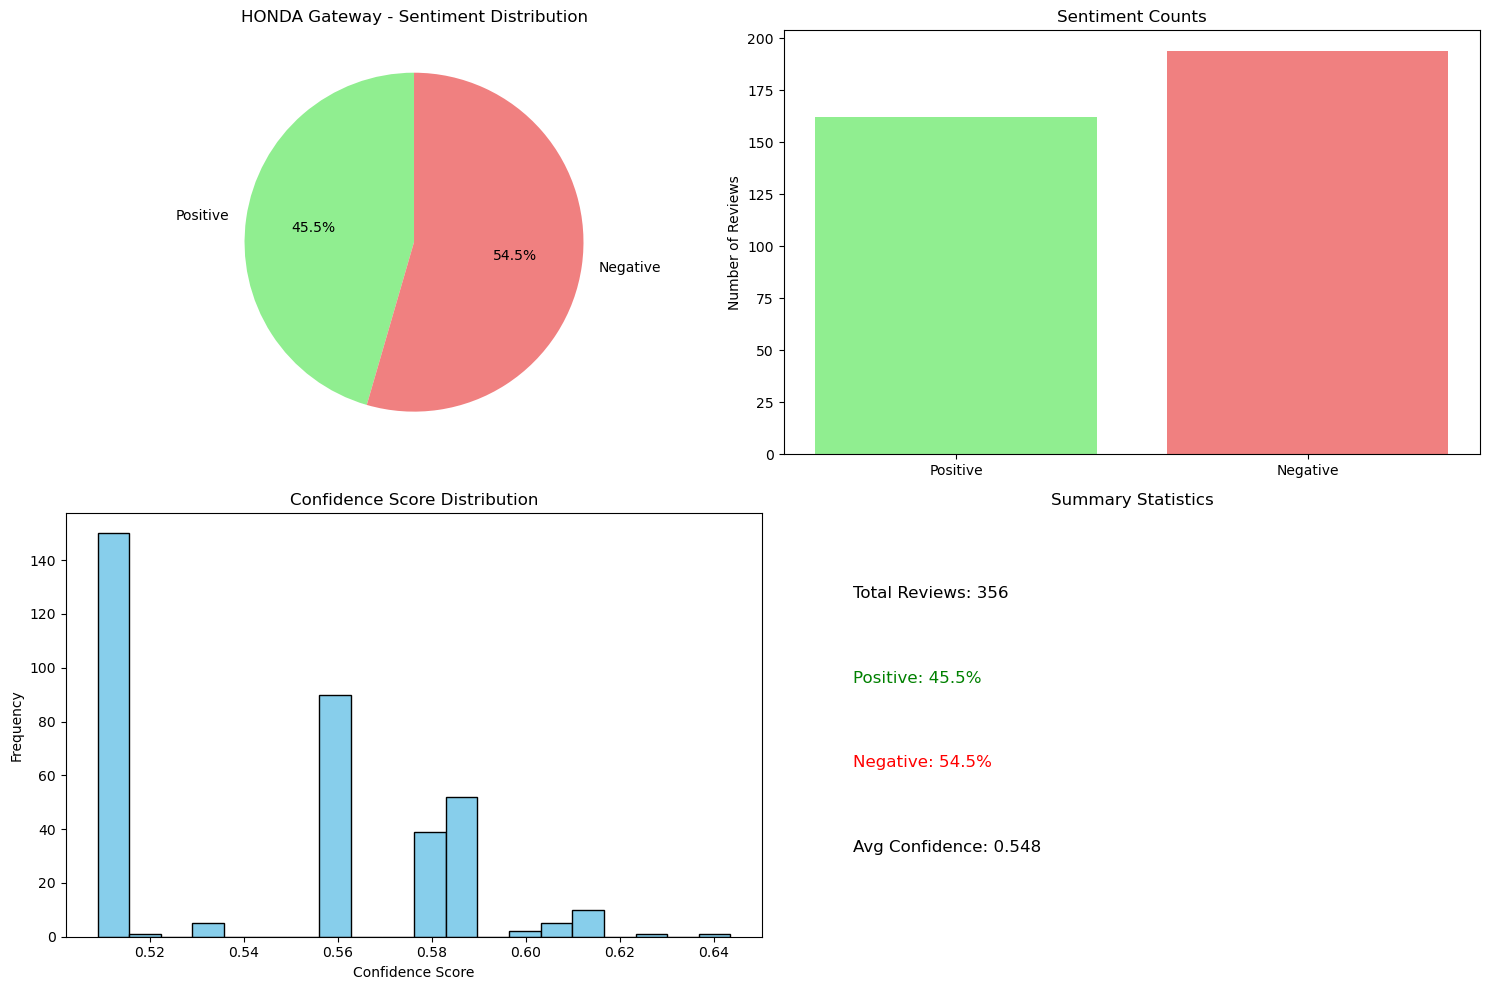


--- Analyzing HONDA Fort ---
✓ Analyzed 349 reviews
  Positive: 51.6%
  Negative: 48.4%


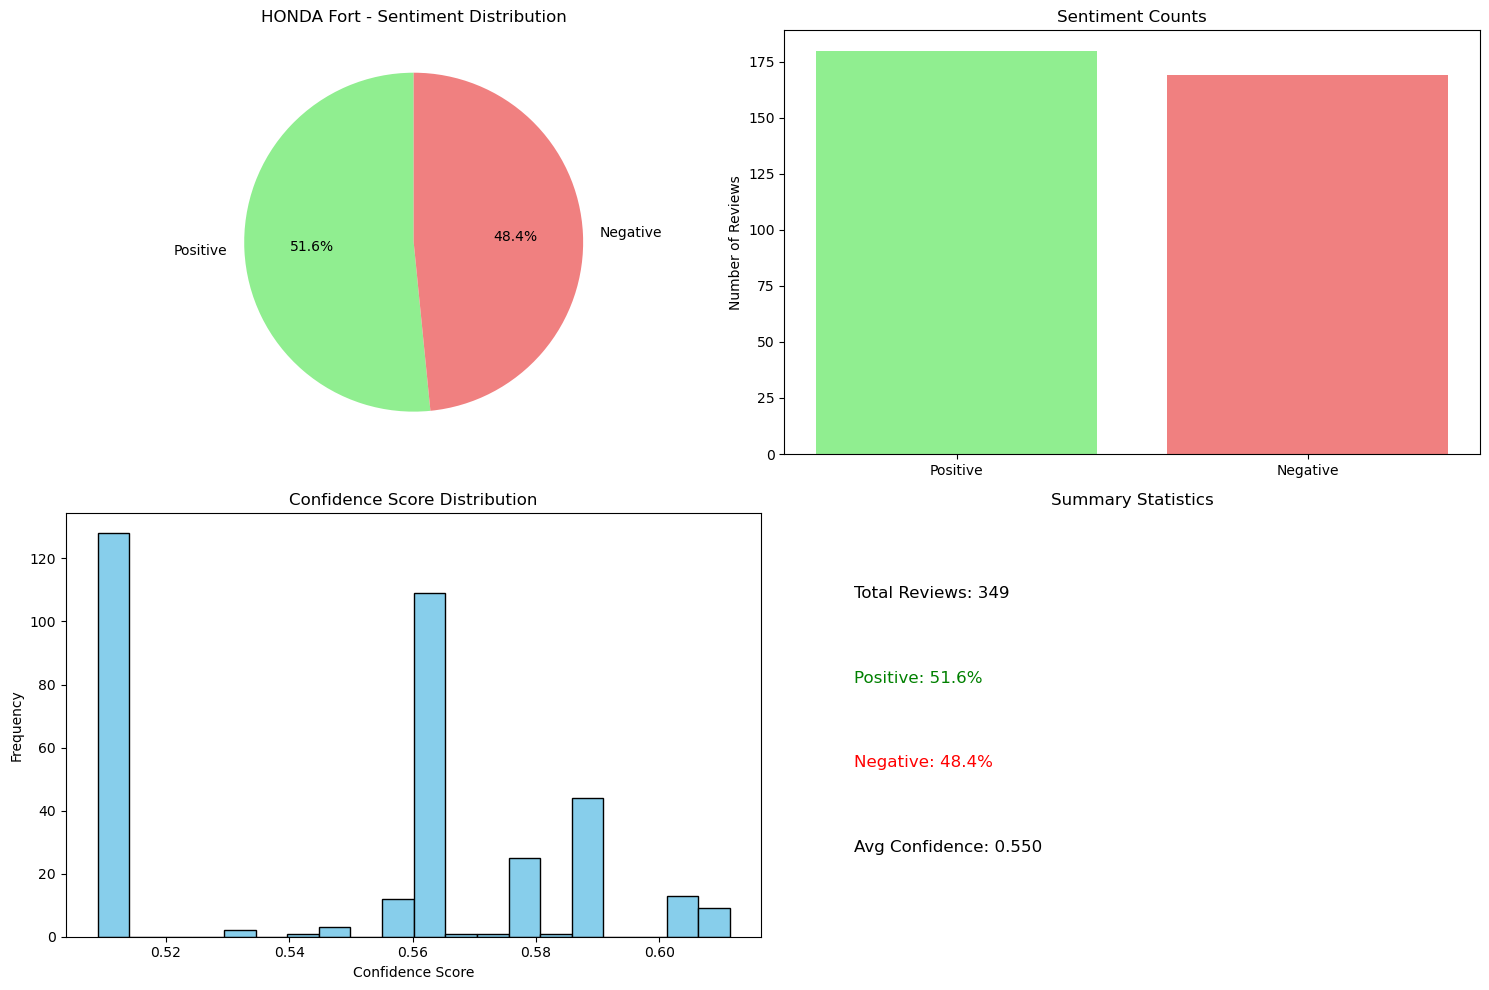


--- Analyzing HONDA RingRoad ---
✓ Analyzed 193 reviews
  Positive: 69.9%
  Negative: 30.1%


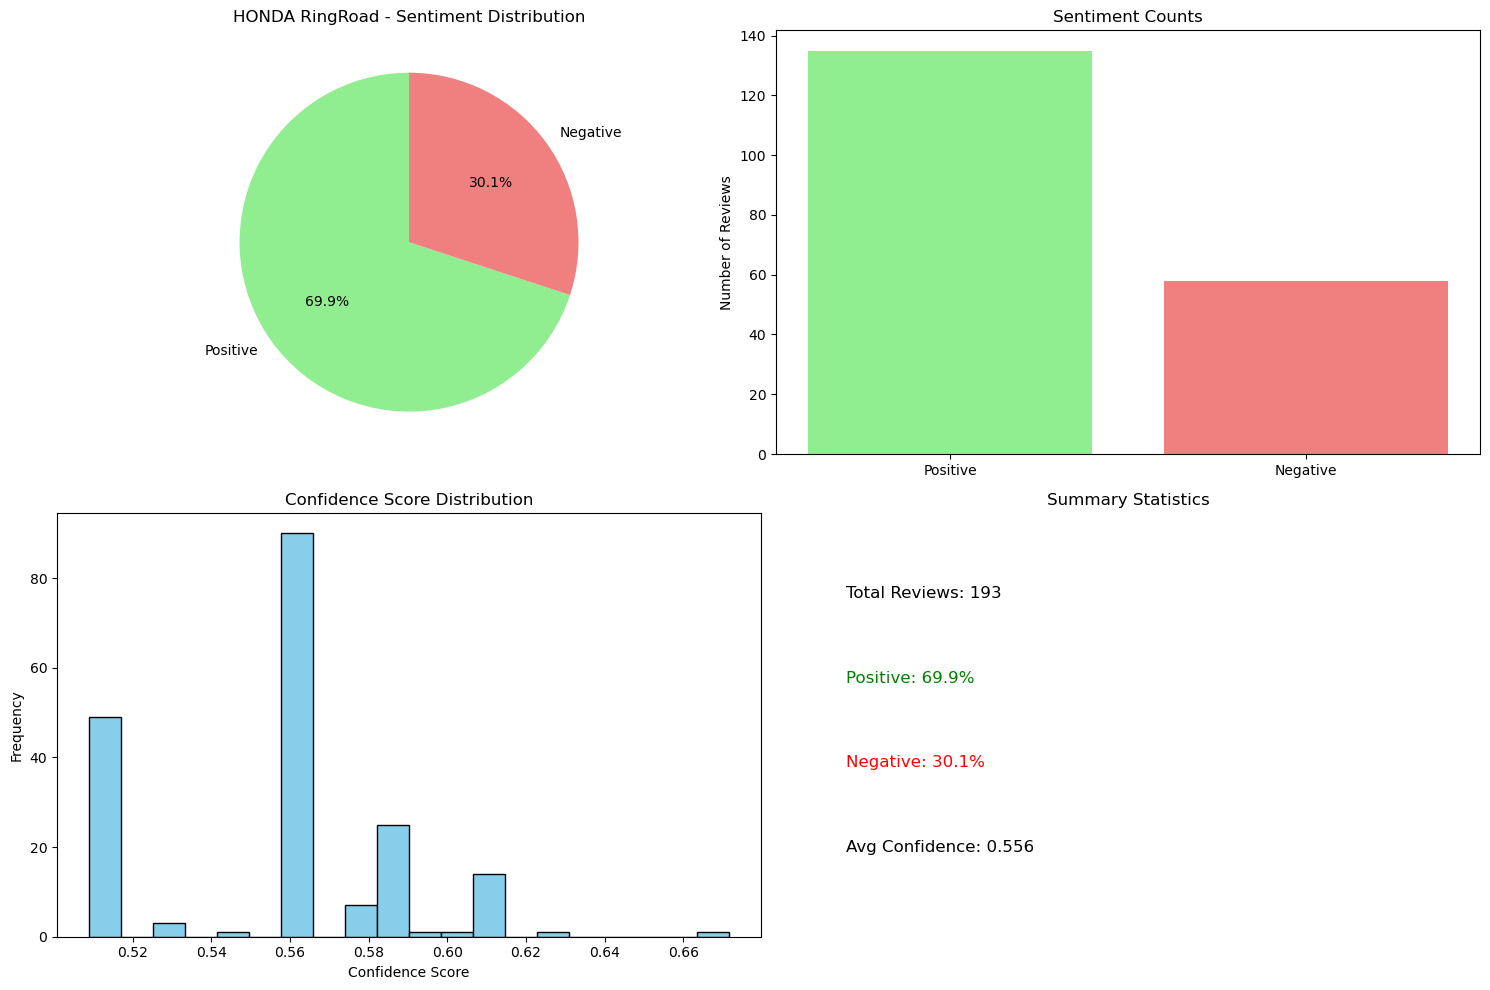


--- Analyzing Suzuki Mini Motors (Gulberg 3) ---
✓ Analyzed 431 reviews
  Positive: 55.0%
  Negative: 45.0%


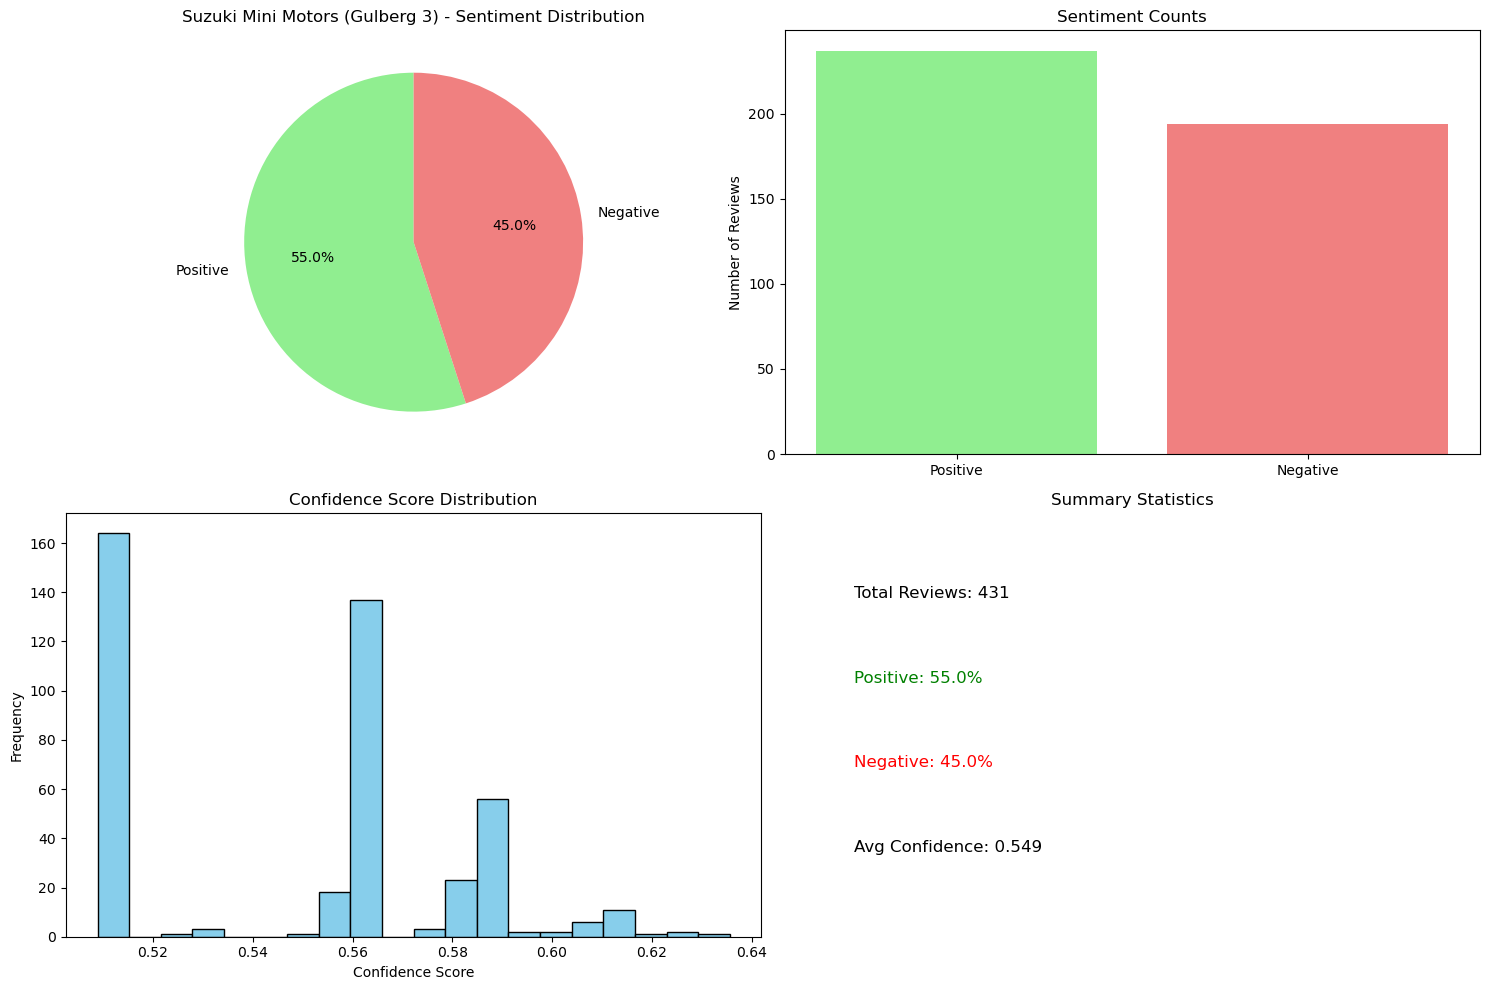


--- Analyzing HONDA Point ---
✓ Analyzed 375 reviews
  Positive: 37.1%
  Negative: 62.9%


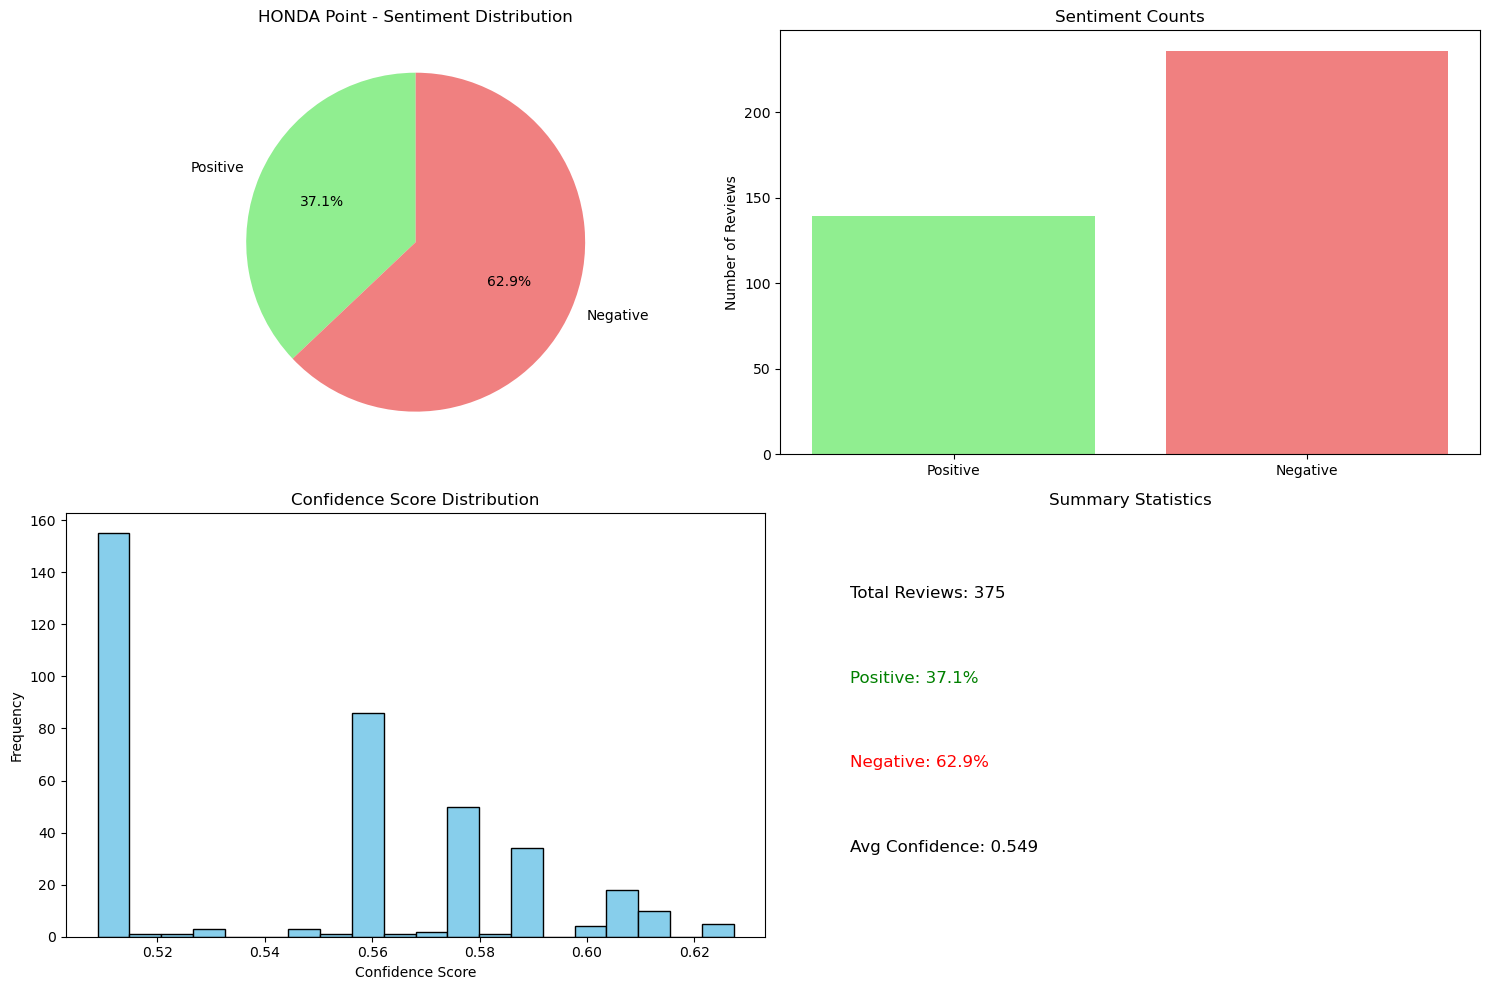


--- Analyzing Suzuki Sethi Motors (Town Morr) ---
✓ Analyzed 656 reviews
  Positive: 48.6%
  Negative: 51.4%


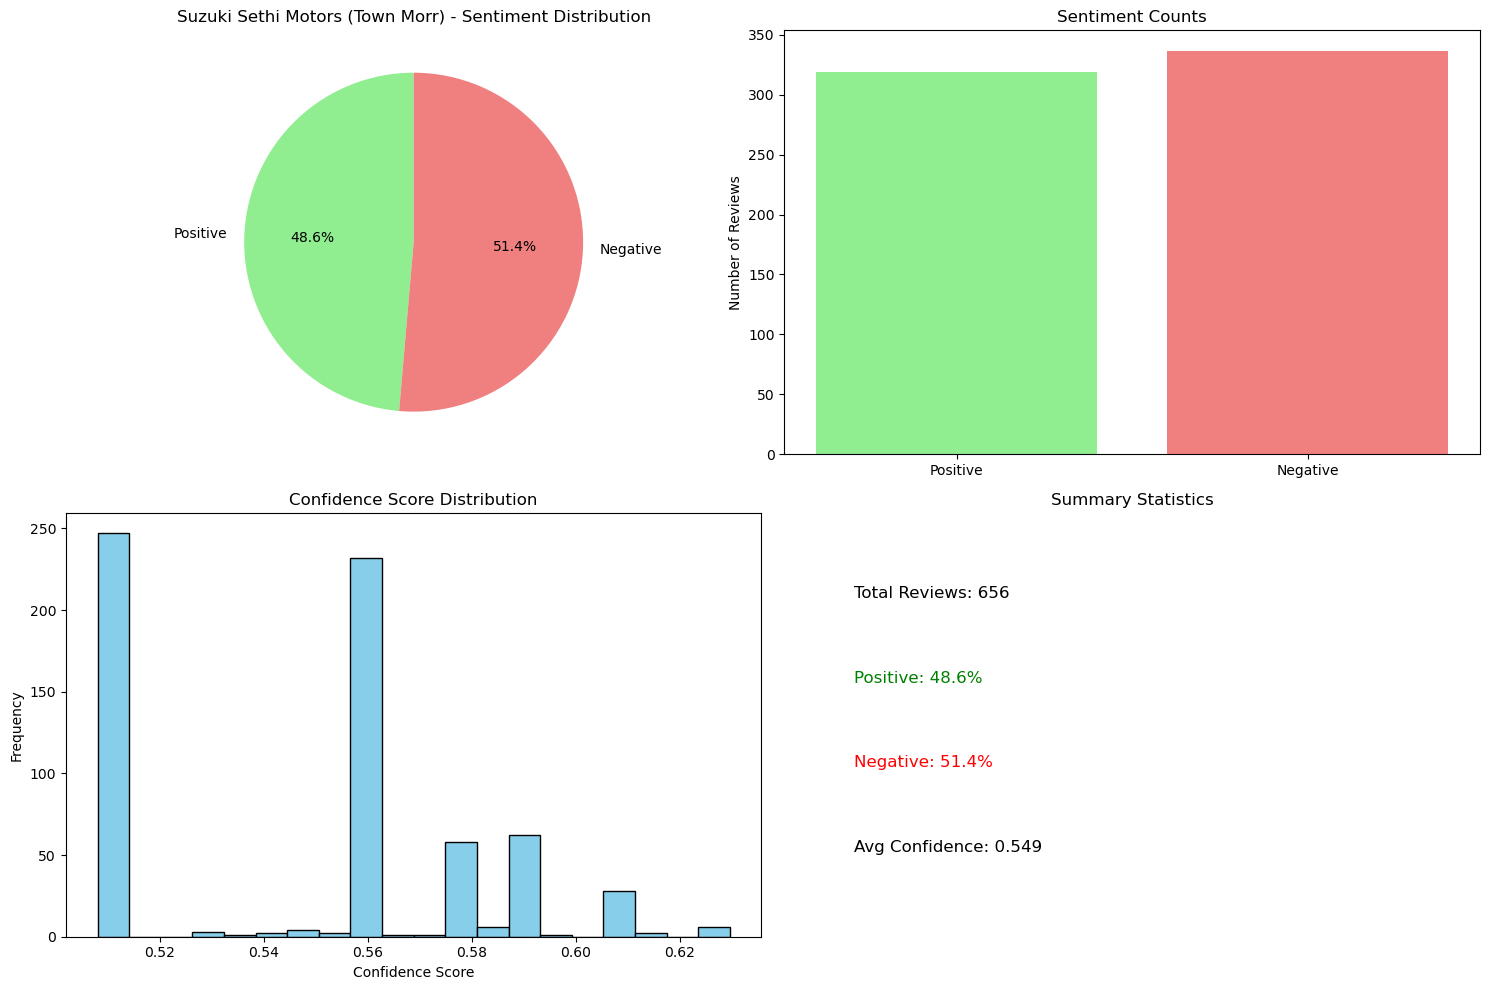


DEALERSHIP SENTIMENT SUMMARY REPORT
                          Dealership  Total Reviews  Positive %  Negative %  Avg Confidence
                      HONDA RingRoad            193        69.9        30.1             0.6
                      HONDA Township            363        59.5        40.5             0.6
      Suzuki Mini Motors (Gulberg 3)            431        55.0        45.0             0.5
                          HONDA Fort            349        51.6        48.4             0.5
            Suzuki Adil Zafar Motors            252        51.2        48.8             0.5
     Suzuki Sethi Motors (Town Morr)            656        48.6        51.4             0.5
Suzuki Khalid Motors (Link Ferozpur)            360        47.8        52.2             0.5
                       HONDA Gateway            356        45.5        54.5             0.5
                    FYP-Testing-Data            971        41.6        58.4             0.5
                         HONDA Point       

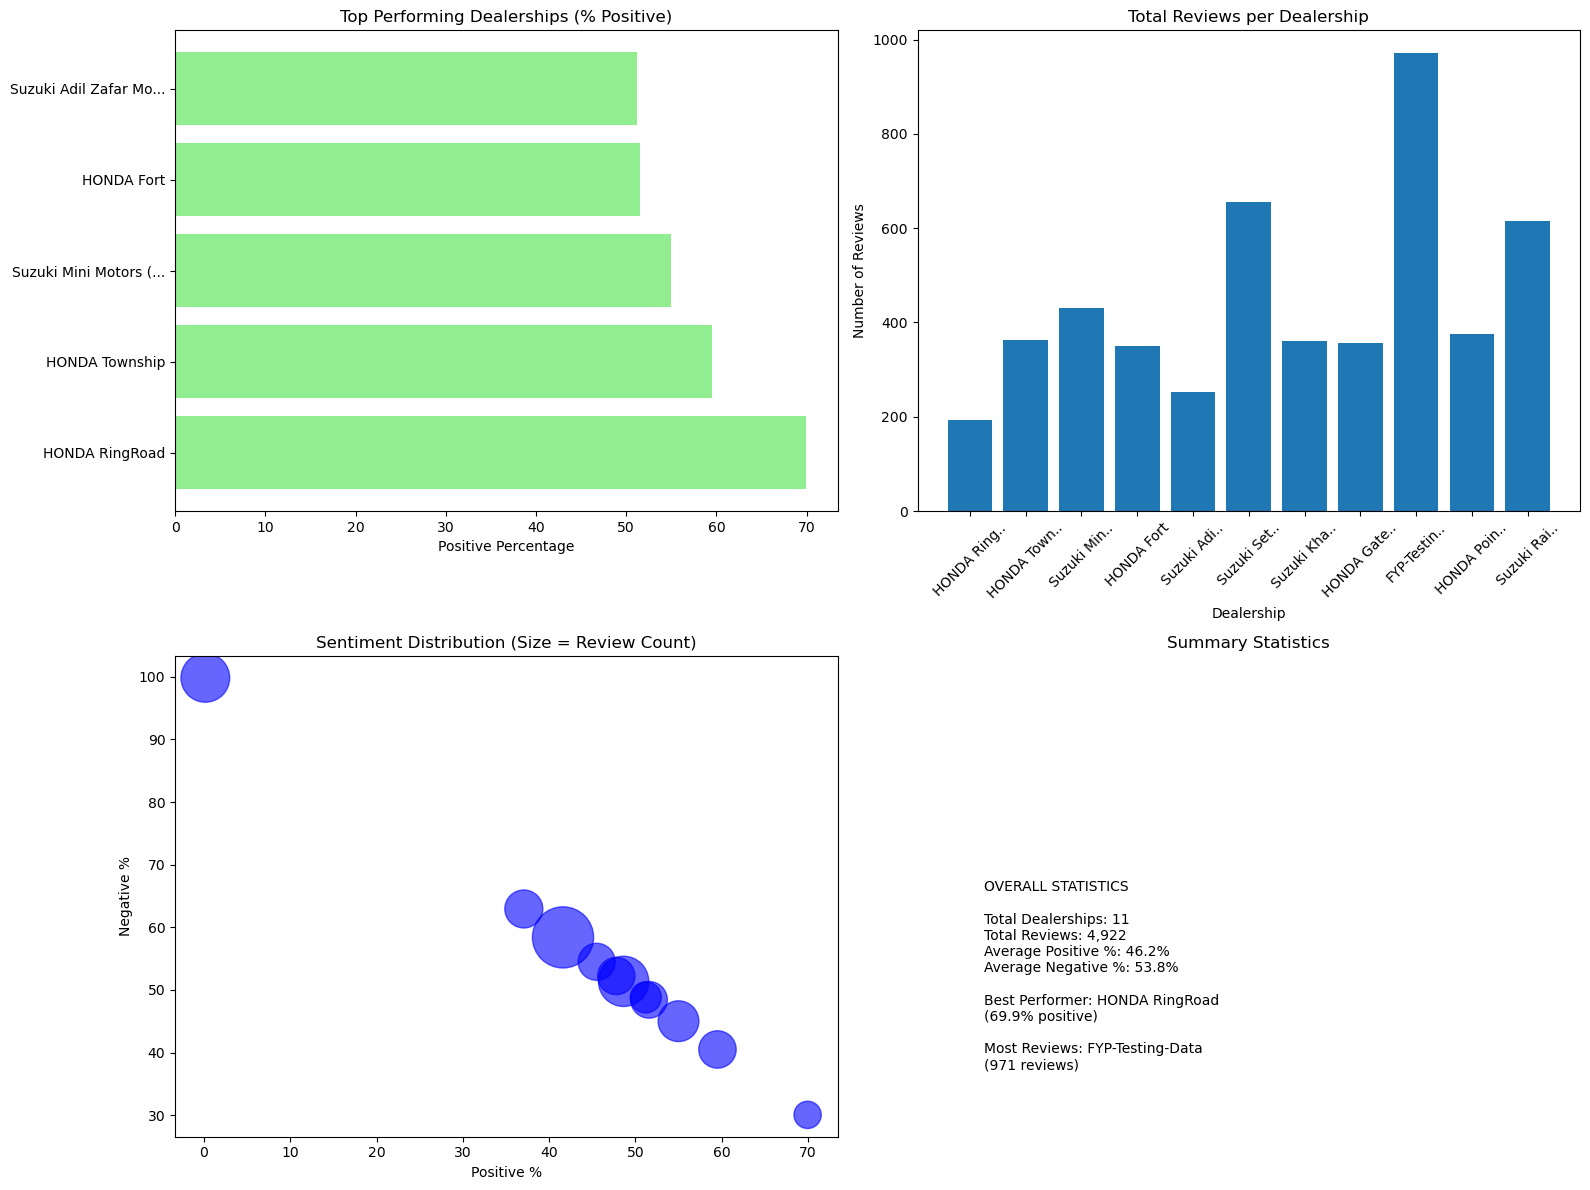


✓ Summary report saved to 'dealership_summary_report.csv'
✓ Summary visualization saved to 'dealership_summary_report.png'


In [8]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from glob import glob
import joblib
import warnings
warnings.filterwarnings('ignore')

class SimpleSentimentAnalyzer:
    def __init__(self):
        self.vectorizer = None
        self.model = None
        self.model_name = None
        
    def clean_text(self, text):
        """Basic text cleaning"""
        if pd.isna(text):
            return ""
        
        text = str(text)
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove user mentions and hashtags for social media text
        text = re.sub(r'@\w+|#\w+', '', text)
        # Remove extra whitespace
        text = ' '.join(text.split())
        # Convert to lowercase
        text = text.lower()
        
        return text
    
    def load_all_data(self, data_directory="./"):
        """Load and combine all CSV files"""
        all_data = []
        
        # Get all CSV files
        csv_files = glob(os.path.join(data_directory, "*.csv"))
        print(f"Found {len(csv_files)} CSV files")
        
        for file_path in csv_files:
            try:
                dealership_name = os.path.basename(file_path).replace('.csv', '')
                df = pd.read_csv(file_path, encoding='unicode_escape')
                df['dealership'] = dealership_name
                all_data.append(df)
                print(f"Loaded {len(df)} records from {dealership_name}")
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
        
        if all_data:
            combined_data = pd.concat(all_data, ignore_index=True)
            print(f"Total records: {len(combined_data)}")
            return combined_data
        else:
            print("No data loaded!")
            return pd.DataFrame()
    
    def prepare_data(self, df, text_column, label_column):
        """Prepare data for training"""
        # Clean the dataframe
        df_clean = df.dropna(subset=[text_column, label_column]).copy()
        
        # Clean text
        df_clean['cleaned_text'] = df_clean[text_column].apply(self.clean_text)
        
        # Standardize labels
        label_map = {
            'positive': 1, 'Positive': 1, 'POSITIVE': 1,
            'negative': 0, 'Negative': 0, 'NEGATIVE': 0,
            1: 1, 0: 0
        }
        
        df_clean['label'] = df_clean[label_column].map(label_map)
        df_clean = df_clean.dropna(subset=['label'])
        
        print(f"Data after cleaning: {len(df_clean)} records")
        print("Label distribution:")
        print(df_clean['label'].value_counts())
        
        return df_clean
    
    def train_multiple_models(self, df, text_column, label_column):
        """Train and compare multiple ML models"""
        # Prepare data
        df_clean = self.prepare_data(df, text_column, label_column)
        
        if len(df_clean) < 10:
            print("Not enough data for training!")
            return None
        
        # Split data
        X = df_clean['cleaned_text']
        y = df_clean['label']
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Vectorize text
        self.vectorizer = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            stop_words='english'
        )
        
        X_train_vec = self.vectorizer.fit_transform(X_train)
        X_test_vec = self.vectorizer.transform(X_test)
        
        # Train multiple models
        models = {
            'Logistic Regression': LogisticRegression(random_state=42),
            'Naive Bayes': MultinomialNB(),
            'SVM': SVC(kernel='linear', random_state=42)
        }
        
        results = {}
        
        print("\nTraining models...")
        for name, model in models.items():
            print(f"Training {name}...")
            
            # Train model
            model.fit(X_train_vec, y_train)
            
            # Make predictions
            y_pred = model.predict(X_test_vec)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            results[name] = {
                'model': model,
                'accuracy': accuracy,
                'predictions': y_pred,
                'classification_report': classification_report(y_test, y_pred, output_dict=True)
            }
            
            print(f"{name} Accuracy: {accuracy:.4f}")
        
        # Select best model
        best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
        self.model = results[best_model_name]['model']
        self.model_name = best_model_name
        
        print(f"\nBest model: {best_model_name} with {results[best_model_name]['accuracy']:.4f} accuracy")
        
        # Save models
        self.save_model()
        
        return results, X_test, y_test
    
    def predict_sentiment(self, text):
        """Predict sentiment for a single text"""
        if not self.model or not self.vectorizer:
            print("Model not trained! Train first or load saved model.")
            return None, None
        
        # Clean and vectorize
        cleaned = self.clean_text(text)
        vectorized = self.vectorizer.transform([cleaned])
        
        # Predict
        prediction = self.model.predict(vectorized)[0]
        
        # Get probability if available
        try:
            probabilities = self.model.predict_proba(vectorized)[0]
            confidence = max(probabilities)
        except:
            confidence = 0.5  # Default confidence for SVM
        
        sentiment = 'Positive' if prediction == 1 else 'Negative'
        return sentiment, confidence
    
    def analyze_dealership_file(self, file_path, text_column):
        """Analyze sentiment for all reviews in a file"""
        df = pd.read_csv(file_path, encoding='unicode_escape')
        
        results = []
        for idx, row in df.iterrows():
            text = str(row[text_column])
            if text and text.strip() and text != 'nan':
                sentiment, confidence = self.predict_sentiment(text)
                results.append({
                    'index': idx,
                    'original_text': text,
                    'predicted_sentiment': sentiment,
                    'confidence': confidence
                })
        
        # Add results to dataframe
        results_df = pd.DataFrame(results)
        if not results_df.empty:
            df['predicted_sentiment'] = ''
            df['confidence'] = ''
            
            for _, result in results_df.iterrows():
                idx = result['index']
                df.at[idx, 'predicted_sentiment'] = result['predicted_sentiment']
                df.at[idx, 'confidence'] = result['confidence']
        
        return df
    
    def generate_insights(self, df, dealership_name):
        """Generate insights for a dealership"""
        total_reviews = len(df[df['predicted_sentiment'].notna()])
        
        if total_reviews == 0:
            return {"error": "No reviews analyzed"}
        
        sentiment_counts = df['predicted_sentiment'].value_counts()
        
        insights = {
            'dealership_name': dealership_name,
            'total_reviews': total_reviews,
            'positive_count': sentiment_counts.get('Positive', 0),
            'negative_count': sentiment_counts.get('Negative', 0),
            'positive_percentage': (sentiment_counts.get('Positive', 0) / total_reviews) * 100,
            'negative_percentage': (sentiment_counts.get('Negative', 0) / total_reviews) * 100,
            'average_confidence': df['confidence'].mean()
        }
        
        return insights
    
    def visualize_results(self, insights, df, dealership_name):
        """Create visualizations"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Pie chart
        labels = ['Positive', 'Negative']
        sizes = [insights['positive_count'], insights['negative_count']]
        colors = ['lightgreen', 'lightcoral']
        
        ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax1.set_title(f'{dealership_name} - Sentiment Distribution')
        
        # Bar chart
        ax2.bar(labels, sizes, color=colors)
        ax2.set_title('Sentiment Counts')
        ax2.set_ylabel('Number of Reviews')
        
        # Confidence histogram
        ax3.hist(df['confidence'].dropna(), bins=20, color='skyblue', edgecolor='black')
        ax3.set_title('Confidence Score Distribution')
        ax3.set_xlabel('Confidence Score')
        ax3.set_ylabel('Frequency')
        
        # Summary text
        ax4.text(0.1, 0.8, f"Total Reviews: {insights['total_reviews']}", fontsize=12)
        ax4.text(0.1, 0.6, f"Positive: {insights['positive_percentage']:.1f}%", fontsize=12, color='green')
        ax4.text(0.1, 0.4, f"Negative: {insights['negative_percentage']:.1f}%", fontsize=12, color='red')
        ax4.text(0.1, 0.2, f"Avg Confidence: {insights['average_confidence']:.3f}", fontsize=12)
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.axis('off')
        ax4.set_title('Summary Statistics')
        
        plt.tight_layout()
        plt.savefig(f'{dealership_name}_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return fig
    
    def save_model(self, filename='simple_sentiment_model.pkl'):
        """Save the trained model and vectorizer"""
        model_data = {
            'vectorizer': self.vectorizer,
            'model': self.model,
            'model_name': self.model_name
        }
        joblib.dump(model_data, filename)
        print(f"Model saved as {filename}")
    
    def create_pretrained_model(self):
        """Create a simple rule-based sentiment model"""
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.linear_model import LogisticRegression
        import numpy as np
        
        # Create a basic vectorizer
        self.vectorizer = TfidfVectorizer(
            max_features=1000,
            ngram_range=(1, 2),
            stop_words='english'
        )
        
        # Create simple positive/negative word lists
        positive_words = [
            'good', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic', 
            'outstanding', 'superb', 'brilliant', 'perfect', 'love', 'best',
            'awesome', 'satisfied', 'happy', 'pleased', 'recommend', 'helpful',
            'friendly', 'professional', 'quality', 'fast', 'efficient'
        ]
        
        negative_words = [
            'bad', 'terrible', 'awful', 'horrible', 'worst', 'hate', 'disgusting',
            'disappointing', 'poor', 'useless', 'pathetic', 'annoying', 'frustrated',
            'angry', 'rude', 'slow', 'expensive', 'cheap', 'broken', 'problem',
            'issue', 'complaint', 'unsatisfied', 'disappointed'
        ]
        
        # Create training sentences
        positive_sentences = [f"This is {word} service" for word in positive_words]
        negative_sentences = [f"This is {word} service" for word in negative_words]
        
        # Combine data
        X_train = positive_sentences + negative_sentences
        y_train = [1] * len(positive_sentences) + [0] * len(negative_sentences)
        
        # Train vectorizer and model
        X_train_vec = self.vectorizer.fit_transform(X_train)
        
        self.model = LogisticRegression(random_state=42)
        self.model.fit(X_train_vec, y_train)
        self.model_name = "Rule-based Pretrained Model"
        
        print("✓ Created rule-based sentiment model")
        
    def create_summary_report(self, all_insights):
        """Create a summary report for all dealerships"""
        import matplotlib.pyplot as plt
        
        if not all_insights:
            print("No insights to summarize")
            return
        
        # Create summary dataframe
        summary_data = []
        for dealership, insights in all_insights.items():
            if 'error' not in insights:
                summary_data.append({
                    'Dealership': dealership,
                    'Total Reviews': insights['total_reviews'],
                    'Positive %': insights['positive_percentage'],
                    'Negative %': insights['negative_percentage'],
                    'Avg Confidence': insights['average_confidence']
                })
        
        if not summary_data:
            print("No valid insights to summarize")
            return
        
        summary_df = pd.DataFrame(summary_data)
        
        # Sort by positive percentage
        summary_df = summary_df.sort_values('Positive %', ascending=False)
        
        # Print summary
        print("\n" + "="*80)
        print("DEALERSHIP SENTIMENT SUMMARY REPORT")
        print("="*80)
        print(summary_df.to_string(index=False, float_format='%.1f'))
        
        # Create summary visualization
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Top/Bottom performers
        top_5 = summary_df.head()
        ax1.barh(range(len(top_5)), top_5['Positive %'], color='lightgreen')
        ax1.set_yticks(range(len(top_5)))
        ax1.set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in top_5['Dealership']])
        ax1.set_title('Top Performing Dealerships (% Positive)')
        ax1.set_xlabel('Positive Percentage')
        
        # Review volume
        ax2.bar(range(len(summary_df)), summary_df['Total Reviews'])
        ax2.set_title('Total Reviews per Dealership')
        ax2.set_xlabel('Dealership')
        ax2.set_ylabel('Number of Reviews')
        ax2.set_xticks(range(len(summary_df)))
        ax2.set_xticklabels([name[:10] + '..' if len(name) > 10 else name for name in summary_df['Dealership']], rotation=45)
        
        # Sentiment distribution scatter
        ax3.scatter(summary_df['Positive %'], summary_df['Negative %'], 
                   s=summary_df['Total Reviews']*2, alpha=0.6, color='blue')
        ax3.set_xlabel('Positive %')
        ax3.set_ylabel('Negative %')
        ax3.set_title('Sentiment Distribution (Size = Review Count)')
        
        # Overall statistics
        avg_positive = summary_df['Positive %'].mean()
        avg_negative = summary_df['Negative %'].mean()
        total_reviews = summary_df['Total Reviews'].sum()
        
        stats_text = f"""OVERALL STATISTICS
        
Total Dealerships: {len(summary_df)}
Total Reviews: {total_reviews:,}
Average Positive %: {avg_positive:.1f}%
Average Negative %: {avg_negative:.1f}%

Best Performer: {summary_df.iloc[0]['Dealership'][:25]}
({summary_df.iloc[0]['Positive %']:.1f}% positive)

Most Reviews: {summary_df.loc[summary_df['Total Reviews'].idxmax(), 'Dealership'][:25]}
({summary_df['Total Reviews'].max():,} reviews)
        """
        
        ax4.text(0.1, 0.1, stats_text, fontsize=10, verticalalignment='bottom')
        ax4.axis('off')
        ax4.set_title('Summary Statistics')
        
        plt.tight_layout()
        plt.savefig('dealership_summary_report.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Save summary to CSV
        summary_df.to_csv('dealership_summary_report.csv', index=False)
        print(f"\n✓ Summary report saved to 'dealership_summary_report.csv'")
        print(f"✓ Summary visualization saved to 'dealership_summary_report.png'")
        
        return summary_df

# Usage Example
def run_analysis_without_labels():
    """Analysis pipeline for unlabeled data using pre-trained model"""
    
    analyzer = SimpleSentimentAnalyzer()
    
    print("=== USING PRE-TRAINED MODEL (No Training Required) ===")
    
    # Create a simple rule-based model for demonstration
    analyzer.create_pretrained_model()
    
    print("\n=== ANALYZING ALL DEALERSHIPS ===")
    
    # Load all data
    all_data = analyzer.load_all_data("./")
    
    if len(all_data) == 0:
        print("No data found!")
        return None
    
    # Get unique dealerships
    dealerships = all_data['dealership'].unique()
    print(f"Found {len(dealerships)} dealerships to analyze")
    
    all_insights = {}
    
    # Analyze each dealership
    for dealership in dealerships:
        print(f"\n--- Analyzing {dealership} ---")
        
        try:
            # Filter data for this dealership
            dealership_data = all_data[all_data['dealership'] == dealership].copy()
            
            # Analyze sentiment
            results = []
            for idx, row in dealership_data.iterrows():
                text = str(row.get('wiI7pd', ''))
                if text and text.strip() and text != 'nan' and len(text) > 10:
                    sentiment, confidence = analyzer.predict_sentiment(text)
                    results.append({
                        'index': idx,
                        'predicted_sentiment': sentiment,
                        'confidence': confidence
                    })
            
            # Add results back to dataframe
            if results:
                for result in results:
                    idx = result['index']
                    dealership_data.at[idx, 'predicted_sentiment'] = result['predicted_sentiment']
                    dealership_data.at[idx, 'confidence'] = result['confidence']
                
                # Generate insights
                insights = analyzer.generate_insights(dealership_data, dealership)
                all_insights[dealership] = insights
                
                print(f"✓ Analyzed {len(results)} reviews")
                print(f"  Positive: {insights['positive_percentage']:.1f}%")
                print(f"  Negative: {insights['negative_percentage']:.1f}%")
                
                # Create visualization
                analyzer.visualize_results(insights, dealership_data, dealership)
                
                # Save individual results
                clean_name = dealership.replace(" ", "_").replace("(", "").replace(")", "")
                dealership_data.to_csv(f"analyzed_{clean_name}.csv", index=False)
                
            else:
                print("  No valid reviews found")
                
        except Exception as e:
            print(f"  Error analyzing {dealership}: {e}")
            continue
    
    # Create summary report
    analyzer.create_summary_report(all_insights)
    
    return analyzer, all_insights

# Test single prediction
def test_prediction():
    """Test the model with a single review"""
    analyzer = SimpleSentimentAnalyzer()
    
    # Try to load existing model
    if not analyzer.load_model():
        print("No saved model found. Train first!")
        return
    
    # Test reviews
    test_reviews = [
        "Great service and friendly staff!",
        "Terrible experience, very disappointed",
        "Average service, nothing special",
        "Excellent dealership, highly recommended"
    ]
    
    print("\nTesting predictions:")
    for review in test_reviews:
        sentiment, confidence = analyzer.predict_sentiment(review)
        print(f"Review: '{review}'")
        print(f"Prediction: {sentiment} (Confidence: {confidence:.3f})\n")

if __name__ == "__main__":
    # Run analysis without training labels
    analyzer, insights = run_analysis_without_labels()
    
    # Test individual predictions if you want
    # test_prediction()

# Manual Labelling

In [13]:
import pandas as pd
import numpy as np
import os
from IPython.display import display, clear_output
import ipywidgets as widgets
from ipywidgets import Button, VBox, HBox, Label, Textarea, IntProgress
import time

class ManualLabelingTool:
    def __init__(self):
        self.current_file = None
        self.current_df = None
        self.current_index = 0
        self.total_reviews = 0
        self.labeled_count = 0
        
    def load_file_for_labeling(self, file_path, text_column="wiI7pd"):
        """Load a CSV file for manual labeling"""
        try:
            self.current_file = file_path
            self.current_df = pd.read_csv(file_path, encoding='unicode_escape')
            self.text_column = text_column
            
            # Add label column if it doesn't exist
            if 'manual_label' not in self.current_df.columns:
                self.current_df['manual_label'] = ''
            
            # Filter out already labeled reviews
            unlabeled = self.current_df[self.current_df['manual_label'] == '']
            self.total_reviews = len(unlabeled)
            self.labeled_count = len(self.current_df) - self.total_reviews
            self.current_index = 0
            
            print(f"✓ Loaded {os.path.basename(file_path)}")
            print(f"  Total reviews: {len(self.current_df)}")
            print(f"  Already labeled: {self.labeled_count}")
            print(f"  Remaining to label: {self.total_reviews}")
            
            return True
            
        except Exception as e:
            print(f"Error loading file: {e}")
            return False
    
    def get_unlabeled_reviews(self):
        """Get list of unlabeled reviews"""
        if self.current_df is None:
            return []
        
        unlabeled = self.current_df[self.current_df['manual_label'] == ''].copy()
        return unlabeled.index.tolist()
    
    def label_review_batch(self, batch_size=50):
        """Label reviews in batches with progress tracking"""
        
        if self.current_df is None:
            print("No file loaded!")
            return
        
        unlabeled_indices = self.get_unlabeled_reviews()
        
        if not unlabeled_indices:
            print("All reviews are already labeled!")
            return
        
        print(f"Starting batch labeling - {min(batch_size, len(unlabeled_indices))} reviews")
        print("Instructions:")
        print("- Read each review carefully")
        print("- Type 'p' for Positive, 'n' for Negative")
        print("- Type 's' to skip, 'q' to quit and save")
        print("-" * 50)
        
        batch_indices = unlabeled_indices[:batch_size]
        labeled_in_batch = 0
        
        for i, idx in enumerate(batch_indices):
            review_text = str(self.current_df.at[idx, self.text_column])
            
            if not review_text or review_text == 'nan' or len(review_text.strip()) < 5:
                # Skip very short or empty reviews
                self.current_df.at[idx, 'manual_label'] = 'skip'
                continue
            
            # Display progress
            clear_output(wait=True)
            progress = (i + 1) / len(batch_indices) * 100
            print(f"Progress: {i+1}/{len(batch_indices)} ({progress:.1f}%)")
            print(f"Total labeled so far: {self.labeled_count + labeled_in_batch}")
            print("-" * 50)
            print(f"Review #{idx}:")
            print(f"Text: {review_text}")
            print("-" * 50)
            
            # Get user input
            while True:
                label = input("Label (p=Positive, n=Negative, s=Skip, q=Quit): ").lower().strip()
                
                if label == 'p':
                    self.current_df.at[idx, 'manual_label'] = 'positive'
                    labeled_in_batch += 1
                    break
                elif label == 'n':
                    self.current_df.at[idx, 'manual_label'] = 'negative'
                    labeled_in_batch += 1
                    break
                elif label == 's':
                    self.current_df.at[idx, 'manual_label'] = 'skip'
                    break
                elif label == 'q':
                    print("Quitting and saving...")
                    self.save_progress()
                    return labeled_in_batch
                else:
                    print("Invalid input! Use p/n/s/q")
        
        # Save progress after batch
        self.save_progress()
        print(f"\n✓ Completed batch! Labeled {labeled_in_batch} reviews")
        
        return labeled_in_batch
    
    def save_progress(self):
        """Save the current progress"""
        if self.current_df is None or self.current_file is None:
            return False
        
        try:
            # Save to original file with backup
            backup_name = self.current_file.replace('.csv', '_backup.csv')
            if os.path.exists(self.current_file):
                pd.read_csv(self.current_file, encoding='unicode_escape').to_csv(backup_name, index=False)
            
            # Save updated file
            self.current_df.to_csv(self.current_file, index=False)
            print(f"✓ Progress saved to {self.current_file}")
            return True
            
        except Exception as e:
            print(f"Error saving: {e}")
            return False
    
    def show_labeling_stats(self):
        """Show current labeling statistics"""
        if self.current_df is None:
            print("No file loaded!")
            return
        
        total = len(self.current_df)
        labeled = len(self.current_df[self.current_df['manual_label'].isin(['positive', 'negative'])])
        skipped = len(self.current_df[self.current_df['manual_label'] == 'skip'])
        remaining = total - labeled - skipped
        
        positive = len(self.current_df[self.current_df['manual_label'] == 'positive'])
        negative = len(self.current_df[self.current_df['manual_label'] == 'negative'])
        
        print(f"Labeling Statistics for {os.path.basename(self.current_file)}:")
        print(f"  Total reviews: {total}")
        print(f"  Labeled: {labeled} ({labeled/total*100:.1f}%)")
        print(f"  - Positive: {positive}")
        print(f"  - Negative: {negative}")
        print(f"  Skipped: {skipped}")
        print(f"  Remaining: {remaining}")
        
        if labeled > 0:
            pos_pct = positive / labeled * 100
            print(f"  Current sentiment: {pos_pct:.1f}% positive, {100-pos_pct:.1f}% negative")
    
    def quick_label_obvious_cases(self):
        """Automatically label obvious positive/negative cases"""
        if self.current_df is None:
            return 0
        
        # Define obvious positive/negative keywords
        strong_positive = ['excellent', 'amazing', 'outstanding', 'fantastic', 'perfect', 'love it', 'highly recommend']
        strong_negative = ['terrible', 'awful', 'worst', 'horrible', 'hate', 'disgusting', 'never again']
        
        auto_labeled = 0
        unlabeled_mask = self.current_df['manual_label'] == ''
        
        for idx in self.current_df[unlabeled_mask].index:
            text = str(self.current_df.at[idx, self.text_column]).lower()
            
            if any(word in text for word in strong_positive):
                if not any(word in text for word in strong_negative):  # Make sure it's not mixed
                    self.current_df.at[idx, 'manual_label'] = 'positive'
                    auto_labeled += 1
            elif any(word in text for word in strong_negative):
                if not any(word in text for word in strong_positive):  # Make sure it's not mixed
                    self.current_df.at[idx, 'manual_label'] = 'negative'
                    auto_labeled += 1
        
        print(f"✓ Auto-labeled {auto_labeled} obvious cases")
        return auto_labeled

class LabelingManager:
    def __init__(self):
        self.labeler = ManualLabelingTool()
        self.files_info = {}
    
    def scan_files(self, directory="./"):
        """Scan all CSV files and show labeling status"""
        csv_files = [f for f in os.listdir(directory) if f.endswith('.csv') and not f.endswith('_backup.csv')]
        
        print("DEALERSHIP LABELING STATUS")
        print("=" * 60)
        
        for file in csv_files:
            file_path = os.path.join(directory, file)
            try:
                df = pd.read_csv(file_path, encoding='unicode_escape')
                total = len(df)
                
                if 'manual_label' in df.columns:
                    labeled = len(df[df['manual_label'].isin(['positive', 'negative'])])
                    progress = labeled / total * 100
                else:
                    labeled = 0
                    progress = 0
                
                self.files_info[file] = {
                    'total': total,
                    'labeled': labeled,
                    'progress': progress
                }
                
                status = "✓ Complete" if progress == 100 else f"{progress:.1f}% done"
                print(f"{file:<35} | {total:>4} reviews | {status}")
                
            except Exception as e:
                print(f"{file:<35} | ERROR: {e}")
        
        print("=" * 60)
        
        # Show recommendations
        unlabeled_files = [f for f, info in self.files_info.items() if info['progress'] < 100]
        if unlabeled_files:
            # Sort by total reviews (start with smaller files)
            unlabeled_files.sort(key=lambda f: self.files_info[f]['total'])
            print(f"\nRECOMMENDED ORDER (start with smaller files):")
            for i, file in enumerate(unlabeled_files[:5], 1):
                info = self.files_info[file]
                print(f"{i}. {file} ({info['total']} reviews)")
    
    def start_labeling_session(self, filename, batch_size=20):
        """Start a labeling session for a specific file"""
        if not os.path.exists(filename):
            print(f"File {filename} not found!")
            return
        
        print(f"Starting labeling session for {filename}")
        
        # Load file
        if not self.labeler.load_file_for_labeling(filename):
            return
        
        # Show current stats
        self.labeler.show_labeling_stats()
        
        # Auto-label obvious cases first
        auto_labeled = self.labeler.quick_label_obvious_cases()
        if auto_labeled > 0:
            self.labeler.save_progress()
            self.labeler.show_labeling_stats()
        
        # Start manual labeling
        while True:
            remaining = len(self.labeler.get_unlabeled_reviews())
            if remaining == 0:
                print("🎉 All reviews labeled for this file!")
                break
            
            print(f"\n{remaining} reviews remaining")
            action = input("Continue labeling? (y=yes, n=no, s=stats): ").lower().strip()
            
            if action == 'y':
                self.labeler.label_review_batch(batch_size)
            elif action == 's':
                self.labeler.show_labeling_stats()
            else:
                break
        
        print("Session ended. Progress saved.")

# Usage functions
def start_labeling():
    """Easy function to start labeling process"""
    manager = LabelingManager()
    
    # Show all files and their status
    manager.scan_files()
    
    # Get file to label
    filename = input("\nEnter filename to label (or press Enter to exit): ").strip()
    if filename:
        manager.start_labeling_session(filename, batch_size=20)

def quick_stats():
    """Show quick stats for all files"""
    manager = LabelingManager()
    manager.scan_files()

# Usage examples
if __name__ == "__main__":
    # Show current status of all files
    quick_stats()
    
    # Uncomment to start labeling
    start_labeling()

DEALERSHIP LABELING STATUS
FYP-Testing-Data.csv                | 1377 reviews | 0.0% done
Suzuki Khalid Motors (Link Ferozpur).csv |  458 reviews | 0.0% done
Suzuki Adil Zafar Motors.csv        |  298 reviews | 0.0% done
Suzuki Raiwing Motors (Raiwind Rd).csv |  664 reviews | 0.0% done
HONDA Township.csv                  |  429 reviews | 0.0% done
HONDA Gateway.csv                   |  429 reviews | 0.0% done
HONDA Fort.csv                      |  412 reviews | 0.0% done
HONDA RingRoad.csv                  |  209 reviews | 14.4% done
Suzuki Mini Motors (Gulberg 3).csv  |  527 reviews | 0.0% done
HONDA Point.csv                     |  440 reviews | 0.0% done
Suzuki Sethi Motors (Town Morr).csv |  759 reviews | 0.0% done

RECOMMENDED ORDER (start with smaller files):
1. HONDA RingRoad.csv (209 reviews)
2. Suzuki Adil Zafar Motors.csv (298 reviews)
3. HONDA Fort.csv (412 reviews)
4. HONDA Township.csv (429 reviews)
5. HONDA Gateway.csv (429 reviews)
DEALERSHIP LABELING STATUS
FYP-Testing-


Enter filename to label (or press Enter to exit):  HONDA RingRoad.csv


Starting labeling session for HONDA RingRoad.csv
✓ Loaded HONDA RingRoad.csv
  Total reviews: 209
  Already labeled: 209
  Remaining to label: 0
Labeling Statistics for HONDA RingRoad.csv:
  Total reviews: 209
  Labeled: 30 (14.4%)
  - Positive: 28
  - Negative: 2
  Skipped: 0
  Remaining: 179
  Current sentiment: 93.3% positive, 6.7% negative
✓ Auto-labeled 0 obvious cases
🎉 All reviews labeled for this file!
Session ended. Progress saved.
